# Shor's Algorithm Circuit Analysis
### Part 1: Quantum Circuit Analysis — Student A Deliverable

This notebook implements Shor's factoring algorithm entirely from scratch using Qiskit 2.x.
It covers QFT construction, Shor's period-finding circuit, classical post-processing via
continued fractions, circuit complexity measurement, and extrapolation to RSA-2048 scale.

## 1. Imports

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_aer import AerSimulator
import random

## 2. Quantum Fourier Transform (QFT) from Scratch

The QFT maps a computational basis state $|x\rangle$ to a superposition of all basis states
with phases proportional to their inner product with $x$.

Construction: for each target qubit (highest to lowest), apply a Hadamard gate, then
controlled-phase rotations from all lower-index qubits. Finally, swap qubits to restore
big-endian ordering.

Target: 3, control: 2, k: 2, angle: 1.5707963267948966
Target: 3, control: 1, k: 3, angle: 0.7853981633974483
Target: 3, control: 0, k: 4, angle: 0.39269908169872414
Target: 2, control: 1, k: 2, angle: 1.5707963267948966
Target: 2, control: 0, k: 3, angle: 0.7853981633974483
Target: 1, control: 0, k: 2, angle: 1.5707963267948966


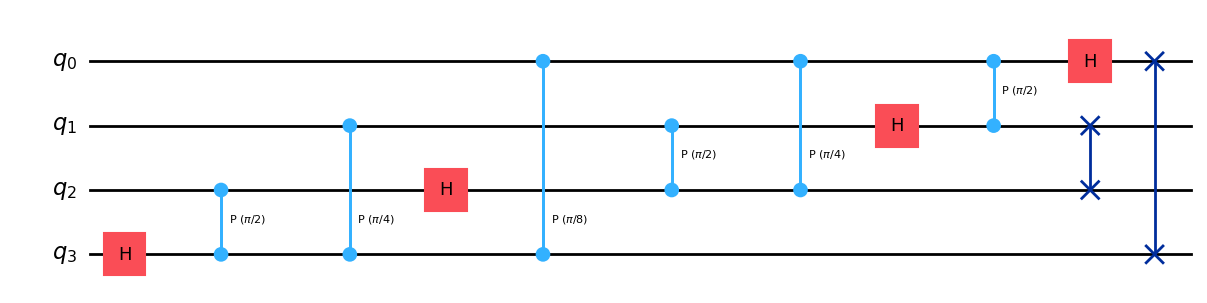

In [3]:
def create_qft_circuit(n):
    qc = QuantumCircuit(n, name="QFT")
    for target in range(n - 1, -1, -1):
        qc.h(target)
        for control in range(target - 1, -1, -1):
            k = target - control + 1
            angle = 2 * math.pi / (2 ** k)
            print(f"Target: {target}, control: {control}, k: {k}, angle: {angle}")
            qc.cp(angle, control, target)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc


def create_inverse_qft_circuit(n):
    qc = QuantumCircuit(n, name="IQFT")
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    for target in range(n):
        for control in range(target):
            k = target - control + 1
            angle = -2 * math.pi / (2 ** k)
            qc.cp(angle, control, target)
        qc.h(target)
    return qc


qft = create_qft_circuit(4)
qft.draw(output="mpl")

### 2.1 QFT Verification

Three checks confirm correctness:
1. **Identity check** — QFT followed by IQFT must return the identity matrix.
2. **Forward match** — our QFT unitary must match Qiskit's built-in.
3. **Inverse match** — our IQFT unitary must match the inverse of Qiskit's built-in.

In [4]:
n_qubits = 4

qc_identity = QuantumCircuit(n_qubits)
qc_identity.append(create_qft_circuit(n_qubits), range(n_qubits))
qc_identity.append(create_inverse_qft_circuit(n_qubits), range(n_qubits))
is_identity = np.allclose(Operator(qc_identity).data, np.eye(2 ** n_qubits))
print(f"QFT x IQFT == Identity  : {is_identity}")

op_custom  = Operator(create_qft_circuit(n_qubits))
op_builtin = Operator(QFT(num_qubits=n_qubits, do_swaps=True))
print(f"Custom QFT == Built-in  : {np.allclose(op_custom.data, op_builtin.data)}")

op_custom_inv  = Operator(create_inverse_qft_circuit(n_qubits))
op_builtin_inv = Operator(QFT(num_qubits=n_qubits, do_swaps=True).inverse())
print(f"Custom IQFT == Built-in : {np.allclose(op_custom_inv.data, op_builtin_inv.data)}")

Target: 3, control: 2, k: 2, angle: 1.5707963267948966
Target: 3, control: 1, k: 3, angle: 0.7853981633974483
Target: 3, control: 0, k: 4, angle: 0.39269908169872414
Target: 2, control: 1, k: 2, angle: 1.5707963267948966
Target: 2, control: 0, k: 3, angle: 0.7853981633974483
Target: 1, control: 0, k: 2, angle: 1.5707963267948966
QFT x IQFT == Identity  : True
Target: 3, control: 2, k: 2, angle: 1.5707963267948966
Target: 3, control: 1, k: 3, angle: 0.7853981633974483
Target: 3, control: 0, k: 4, angle: 0.39269908169872414
Target: 2, control: 1, k: 2, angle: 1.5707963267948966
Target: 2, control: 0, k: 3, angle: 0.7853981633974483
Target: 1, control: 0, k: 2, angle: 1.5707963267948966
Custom QFT == Built-in  : True
Custom IQFT == Built-in : True


C:\Users\fraud\AppData\Local\Temp\ipykernel_27896\3581257241.py:10: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  op_builtin = Operator(QFT(num_qubits=n_qubits, do_swaps=True))
C:\Users\fraud\AppData\Local\Temp\ipykernel_27896\3581257241.py:14: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  op_builtin_inv = Operator(QFT(num_qubits=n_qubits, do_swaps=True).inverse())


### 2.2 QFT Circuit Diagram

Target: 9, control: 8, k: 2, angle: 1.5707963267948966
Target: 9, control: 7, k: 3, angle: 0.7853981633974483
Target: 9, control: 6, k: 4, angle: 0.39269908169872414
Target: 9, control: 5, k: 5, angle: 0.19634954084936207
Target: 9, control: 4, k: 6, angle: 0.09817477042468103
Target: 9, control: 3, k: 7, angle: 0.04908738521234052
Target: 9, control: 2, k: 8, angle: 0.02454369260617026
Target: 9, control: 1, k: 9, angle: 0.01227184630308513
Target: 9, control: 0, k: 10, angle: 0.006135923151542565
Target: 8, control: 7, k: 2, angle: 1.5707963267948966
Target: 8, control: 6, k: 3, angle: 0.7853981633974483
Target: 8, control: 5, k: 4, angle: 0.39269908169872414
Target: 8, control: 4, k: 5, angle: 0.19634954084936207
Target: 8, control: 3, k: 6, angle: 0.09817477042468103
Target: 8, control: 2, k: 7, angle: 0.04908738521234052
Target: 8, control: 1, k: 8, angle: 0.02454369260617026
Target: 8, control: 0, k: 9, angle: 0.01227184630308513
Target: 7, control: 6, k: 2, angle: 1.570796326794

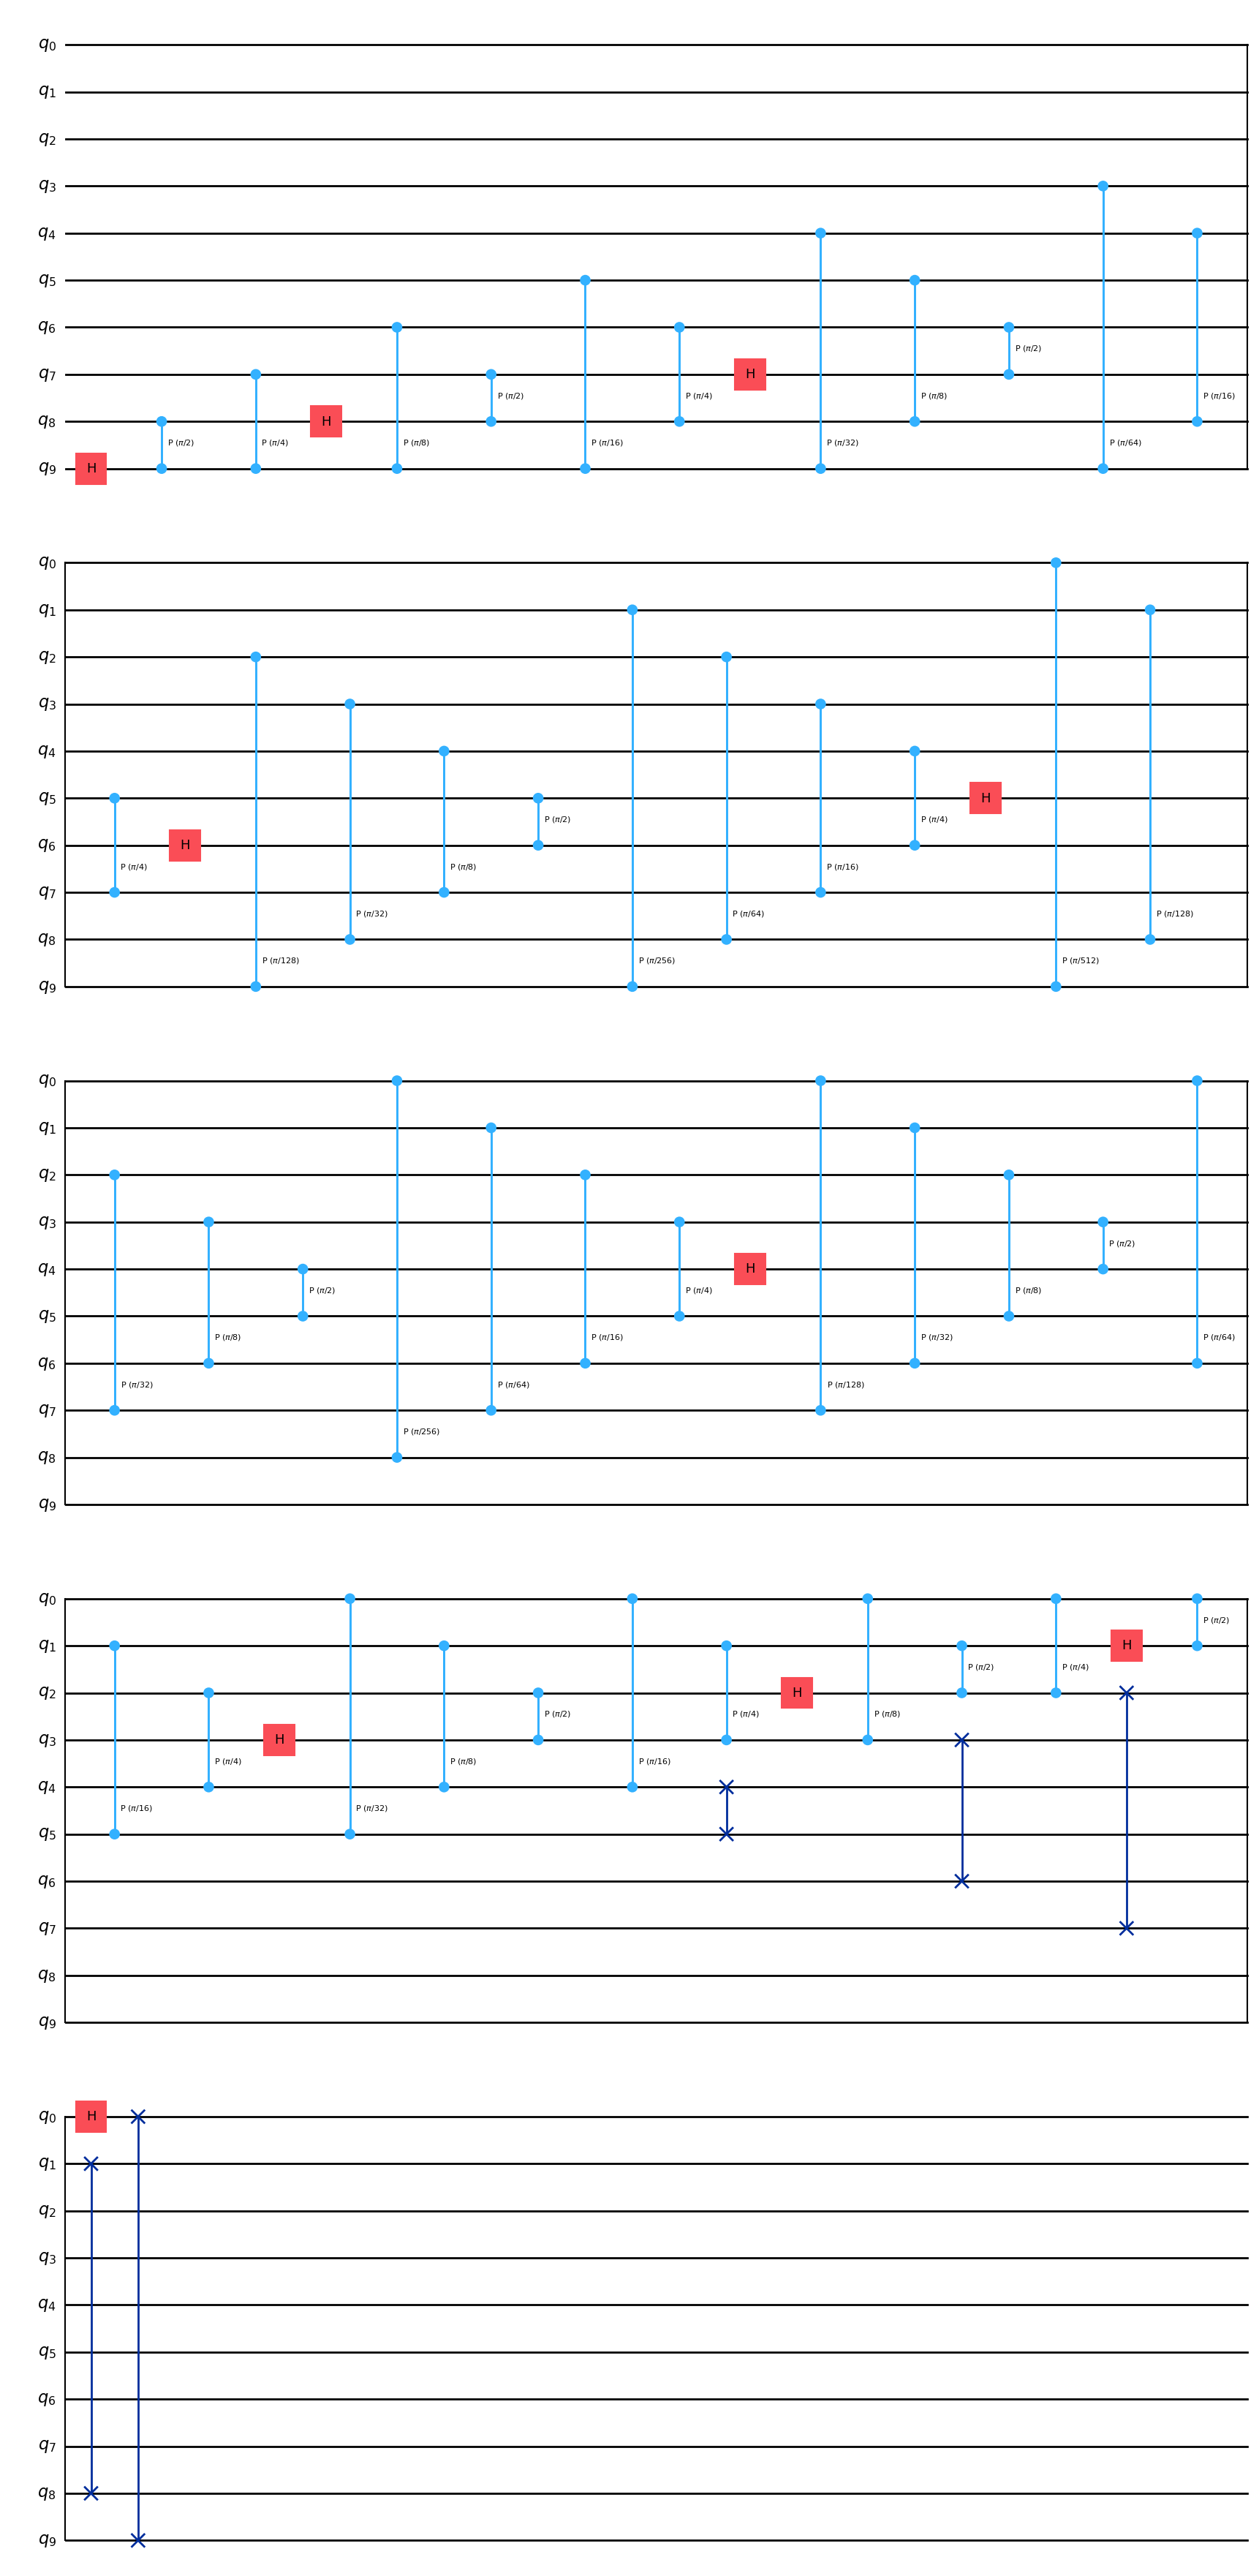

In [5]:
create_qft_circuit(10).draw(output='mpl')

## 3. Shor's Period-Finding Circuit

Shor's algorithm finds the period $r$ of the function $f(x) = a^x \pmod N$.
If $r$ is even and $a^{r/2} \not\equiv -1 \pmod N$, then
$\gcd(a^{r/2} \pm 1,\, N)$ yields a non-trivial factor.

**Circuit layout:**
- Qubits $[0 \ldots t-1]$ — counting register (receives IQFT)
- Qubits $[t \ldots t+m-1]$ — target register (stores $a^x \bmod N$)

where $m = \lceil \log_2 N \rceil$ and $t = 2m$.

In [6]:
def smallest_coprime(N):
    coprimes = []
    for a in range(2, N):
        if math.gcd(a, N) == 1:
            coprimes.append(a)
    if len(coprimes)!=0:
        return random.choice(coprimes)
    raise ValueError(f"No coprime found for N={N}")

def compute_shor_params(N, a=None):
    m = math.ceil(math.log2(N))
    t = 2 * m
    if a is None:
        a = smallest_coprime(N)
    else:
        if not (2 <= a < N):
            raise ValueError(f"Base a={a} must satisfy 2 <= a < N={N}.")
        if math.gcd(a, N) != 1:
            raise ValueError(f"a={a} is not coprime with N={N}.")
    return t, m, a


def get_mod_mult_matrix(a, power, N, m):
    dim = 2 ** m
    matrix = np.zeros((dim, dim))
    for y in range(dim):
        if y < N:
            target = (y * pow(a, power, N)) % N
            matrix[target, y] = 1.0
        else:
            matrix[y, y] = 1.0
    return matrix


def create_shors_circuit(N, a=None):
    t, m, a = compute_shor_params(N, a)
    print(f"  N={N}, a={a}, t={t} counting qubits, m={m} target qubits, total={t+m}")
    qc = QuantumCircuit(t + m, t, name=f"Shors_N{N}_a{a}")
    for i in range(t):
        qc.h(i)
    qc.x(t)
    for i in range(t):
        matrix = get_mod_mult_matrix(a, 2 ** i, N, m)
        gate = UnitaryGate(matrix, label=f"{a}^{2**i}_mod_{N}")
        qc.append(gate.control(1), [i] + list(range(t, t + m)))
    qc.append(create_inverse_qft_circuit(t), range(t))
    qc.measure(range(t), range(t))
    return qc, t, m, a

## 4. Classical Post-Processing — Continued Fractions

The QPE measurement yields an integer $s$ such that $s/2^t \approx k/r$.
The Continued Fractions Algorithm extracts candidate denominators from this fraction;
each denominator is a candidate period $r$.

**Recurrence:**
$$h_n = a_n \cdot h_{n-1} + h_{n-2}, \quad k_n = a_n \cdot k_{n-1} + k_{n-2}$$
Seeds: $h_{-2}=0,\; k_{-2}=1,\; h_{-1}=1,\; k_{-1}=0$

In [7]:
def get_period_candidates(measured_value, t, N):
    phi = measured_value / (2 ** t)
    if phi == 0:
        return []
    cf = []
    val = phi
    for _ in range(20):
        a_i = int(val)
        cf.append(a_i)
        remainder = val - a_i
        if remainder < 1e-10:
            break
        val = 1.0 / remainder
    candidates = []
    p_prev, q_prev = 0, 1
    p_curr, q_curr = 1, 0
    for coeff in cf:
        p_next = coeff * p_curr + p_prev
        q_next = coeff * q_curr + q_prev
        p_prev, q_prev = p_curr, q_curr
        p_curr, q_curr = p_next, q_next
        if 0 < q_curr < N:
            candidates.append(q_curr)
    return list(set(candidates))


def run_shors_simulation(N, a=None, shots=100):
    print(f"  Factoring N = {N}")
    qc, t, m, a_used = create_shors_circuit(N, a)
    simulator = AerSimulator()
    counts = simulator.run(transpile(qc, simulator), shots=shots).result().get_counts()
    print()
    print(f"  Top measurement outcomes (a={a_used}):")
    print(f"  {'Binary':<{t+2}}  {'Dec':>4}  {'Prob':>6}  {'Phase':>8}")
    print(f"  {'-'*45}")
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    for val_str, count in sorted_counts[:10]:
        val_dec = int(val_str, 2)
        print(f"  {val_str:<{t+2}}  {val_dec:>4}  {count/shots:>6.3f}  {val_dec/(2**t):>8.4f}")
    found_factors = set()
    for val_str, _ in sorted_counts:
        val_dec = int(val_str, 2)
        if val_dec == 0:
            continue
        for r in get_period_candidates(val_dec, t, N):
            if pow(a_used, r, N) != 1 or r % 2 != 0:
                continue
            print()
            print(f"  Period r = {r}  (from measured value {val_dec})")
            half = r // 2
            g1 = math.gcd(pow(a_used, half, N) - 1, N)
            g2 = math.gcd(pow(a_used, half, N) + 1, N)
            for g in (g1, g2):
                if 1 < g < N:
                    found_factors.add(g)
                    print(f"    Non-trivial factor: {g}")
    print()
    if found_factors:
        print(f"  SUCCESS: N = {N} = {' x '.join(str(f) for f in sorted(found_factors))}")
    else:
        print("  FAILURE: No factors found.")
    return bool(found_factors), found_factors

## 5. Factoring Runs — N = 15, 21, 35

In [8]:
results = {}
for N in [15, 21, 35]:
    success, factors = run_shors_simulation(N, shots=100)
    results[N] = {'success': success, 'factors': sorted(factors)}
    print()

print(f"{'N':>5}  {'Success':>7}  Factors")
print('-' * 35)
for N, res in results.items():
    flag = "OK" if res['success'] else "FAIL"
    print(f"{N:>5}  {flag:>7}  {res['factors']}")

  Factoring N = 15
  N=15, a=13, t=8 counting qubits, m=4 target qubits, total=12

  Top measurement outcomes (a=13):
  Binary       Dec    Prob     Phase
  ---------------------------------------------
  00000000       0   0.290    0.0000
  10000000     128   0.250    0.5000
  01000000      64   0.240    0.2500
  11000000     192   0.220    0.7500

  Period r = 4  (from measured value 64)
    Non-trivial factor: 3
    Non-trivial factor: 5

  Period r = 4  (from measured value 192)
    Non-trivial factor: 3
    Non-trivial factor: 5

  SUCCESS: N = 15 = 3 x 5

  Factoring N = 21
  N=21, a=10, t=10 counting qubits, m=5 target qubits, total=15

  Top measurement outcomes (a=10):
  Binary         Dec    Prob     Phase
  ---------------------------------------------
  0000000000       0   0.210    0.0000
  1010101011     683   0.150    0.6670
  1101010101     853   0.140    0.8330
  0101010101     341   0.110    0.3330
  0010101011     171   0.100    0.1670
  1000000000     512   0.090   

## 6. Circuit Complexity Measurement

We transpile each Shor's circuit to the universal basis $\{U, CNOT\}$ and extract:
- **Qubit count** — total qubits required
- **Circuit depth** — longest sequential dependency chain
- **CNOT count** — dominant measure of two-qubit gate cost

In [9]:
metrics = []

for N in [15, 21, 35, 121]:
    n_bits = math.ceil(math.log2(N))
    print(f"\n  Measuring complexity for N={N} (n={n_bits} bits)…")

    qc, t_val, m_val, a_val = create_shors_circuit(N)
    qc_trans = transpile(qc, basis_gates=['u', 'cx'], optimization_level=1)

    metrics.append({
        'N':           N,
        'n_bits':      n_bits,
        'a':           a_val,
        'qubits':      qc.num_qubits,
        'raw_depth':   qc.depth(),
        'raw_gates':   sum(qc.count_ops().values()),
        'trans_depth': qc_trans.depth(),
        'trans_gates': sum(qc_trans.count_ops().values()),
        'trans_cx':    qc_trans.count_ops().get('cx', 0),
    })


header = (f"{'N':>5} | {'Bits':>4} | {'a':>4} | "
        f"{'Qubits':>6} | {'Raw Depth':>9} | {'Raw Gates':>9} | "
        f"{'Trans Depth':>11} | {'Trans Gates':>11} | {'CNOTs':>6}")
sep = '-' * len(header)
print(sep)
print("Circuit Complexity Metrics")
print(sep)
print(header)
print(sep)
for row in metrics:
    print(f"{row['N']:>5} | {row['n_bits']:>4} | {row['a']:>4} | "
            f"{row['qubits']:>6} | {row['raw_depth']:>9} | {row['raw_gates']:>9} | "
            f"{row['trans_depth']:>11} | {row['trans_gates']:>11} | {row['trans_cx']:>6}")
print(sep)


  Measuring complexity for N=15 (n=4 bits)…
  N=15, a=4, t=8 counting qubits, m=4 target qubits, total=12

  Measuring complexity for N=21 (n=5 bits)…
  N=21, a=11, t=10 counting qubits, m=5 target qubits, total=15

  Measuring complexity for N=35 (n=6 bits)…
  N=35, a=9, t=12 counting qubits, m=6 target qubits, total=18

  Measuring complexity for N=121 (n=7 bits)…
  N=121, a=86, t=14 counting qubits, m=7 target qubits, total=21
-----------------------------------------------------------------------------------------
Circuit Complexity Metrics
-----------------------------------------------------------------------------------------
    N | Bits |    a | Qubits | Raw Depth | Raw Gates | Trans Depth | Trans Gates |  CNOTs
-----------------------------------------------------------------------------------------
   15 |    4 |    4 |     12 |        11 |        26 |         458 |         789 |    304
   21 |    5 |   11 |     15 |        13 |        32 |       19792 |       27019 |  1014

In [10]:
# metrics = []
# for N in [15, 21, 35, 100]:
#     n_bits = math.ceil(math.log2(N))
#     qc, t_val, m_val, a_val = create_shors_circuit(N)
#     qc_trans = transpile(qc, basis_gates=['u', 'cx'], optimization_level=1)
#     metrics.append({
#         'N':           N,
#         'n_bits':      n_bits,
#         'a':           a_val,
#         'qubits':      qc.num_qubits,
#         'raw_depth':   qc.depth(),
#         'raw_gates':   sum(qc.count_ops().values()),
#         'trans_depth': qc_trans.depth(),
#         'trans_gates': sum(qc_trans.count_ops().values()),
#         'trans_cx':    qc_trans.count_ops().get('cx', 0),
#     })

# header = (f"{'N':>5} | {'Bits':>4} | {'a':>4} | "
#           f"{'Qubits':>6} | {'Raw Depth':>9} | {'Raw Gates':>9} | "
#           f"{'Trans Depth':>11} | {'Trans Gates':>11} | {'CNOTs':>6}")
# sep = '-' * len(header)
# print(sep)
# print("Circuit Complexity Metrics")
# print(sep)
# print(header)
# print(sep)
# for row in metrics:
#     print(f"{row['N']:>5} | {row['n_bits']:>4} | {row['a']:>4} | "
#           f"{row['qubits']:>6} | {row['raw_depth']:>9} | {row['raw_gates']:>9} | "
#           f"{row['trans_depth']:>11} | {row['trans_gates']:>11} | {row['trans_cx']:>6}")
# print(sep)

## 7. Scaling Plots and RSA-2048 Extrapolation

We fit a linear model to the qubit count data (expected $\approx 3n$ since $t = 2m$ and $m = n$)
and a log-scale plot for CNOT count (exponential due to the naive full unitary matrix construction).
The linear fit is projected to $n = 2048$ bits to estimate the logical qubit requirement for RSA-2048.

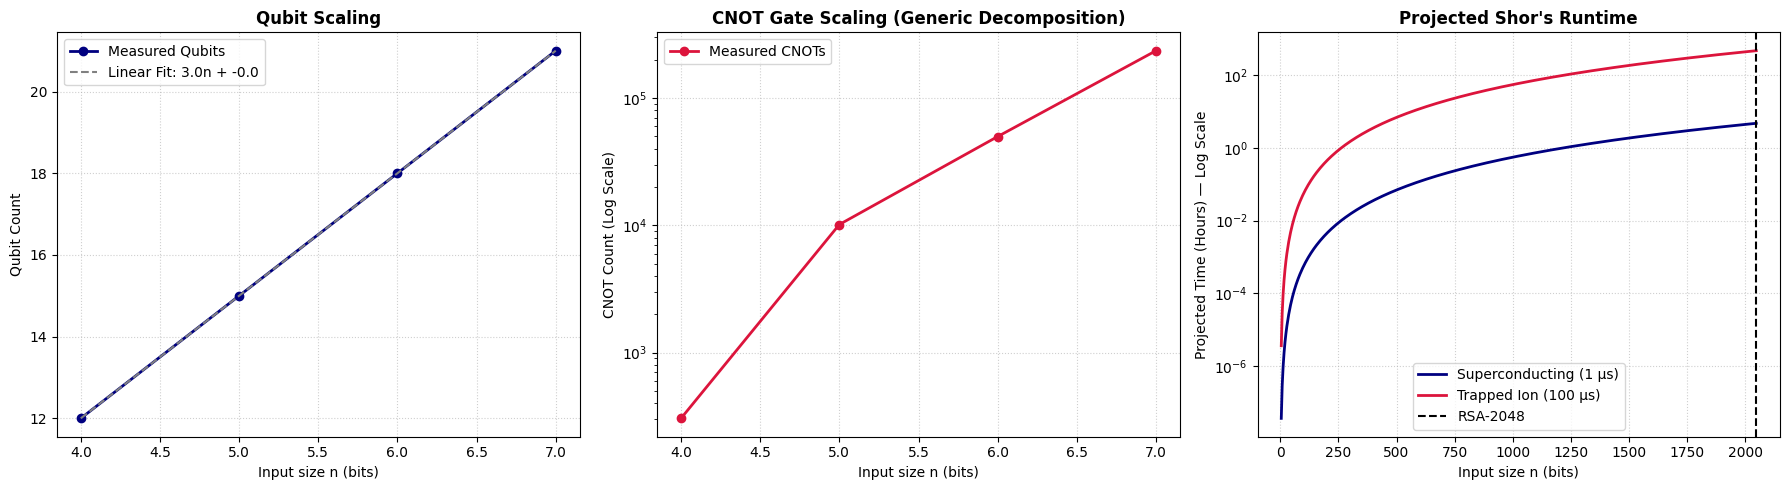

  RSA-2048 SPATIAL EXTRAPOLATION
    From linear fit  : 6,144 logical qubits
    Theory (2n+3)    : 4,099 logical qubits
    Paper Table IV   : ~4000 logical qubits

  RSA-2048 TEMPORAL RUNTIME ESTIMATION
    Total Logical Gates      : 1.72e+10 operations
    Superconducting (1 μs)   : 4.77 hours (competitive with classical scaling)
    Trapped Ion (100 μs)     : 19.88 days
    Paper Claim       : <10 hours (superconducting scale)


In [11]:
bits   = np.array([row['n_bits']   for row in metrics])
qubits = np.array([row['qubits']   for row in metrics])
cnots  = np.array([row['trans_cx'] for row in metrics])

fit_q = np.polyfit(bits, qubits, 1)

# Create high-resolution side-by-side plots for qubits, generic CNOTs, and theoretical runtime scaling
plt.figure(figsize=(18, 5))

# Subplot 1: Qubit Scaling (Linear Fit)
ax1 = plt.subplot(1, 3, 1)
ax1.plot(bits, qubits, 'o-', color='navy', linewidth=2, label='Measured Qubits')
ax1.plot(bits, np.polyval(fit_q, bits), '--', color='grey',
            label=f'Linear Fit: {fit_q[0]:.1f}n + {fit_q[1]:.1f}')
ax1.set_xlabel('Input size n (bits)')
ax1.set_ylabel('Qubit Count')
ax1.set_title('Qubit Scaling', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Subplot 2: CNOT Gate Scaling (Log Scale - Naive generic decomposition)
ax2 = plt.subplot(1, 3, 2)
ax2.semilogy(bits, cnots, 'o-', color='crimson', linewidth=2, label='Measured CNOTs')
ax2.set_xlabel('Input size n (bits)')
ax2.set_ylabel('CNOT Count (Log Scale)')
ax2.set_title('CNOT Gate Scaling (Generic Decomposition)', fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

# Subplot 3: Fault-Tolerant Shor's Factoring Runtime Projection
ax3 = plt.subplot(1, 3, 3)
n_range = np.arange(4, 2049, 4)
c_ripple = 2.0  # constant for carry-ripple arithmetic
tau_sc = 1e-6   # 1 microsecond logical cycle (superconducting)
tau_ion = 1e-4  # 100 microsecond logical cycle (trapped ion)

logical_gates = c_ripple * (n_range ** 3)
time_sc_hours = (logical_gates * tau_sc) / 3600.0
time_ion_hours = (logical_gates * tau_ion) / 3600.0

ax3.plot(n_range, time_sc_hours, label='Superconducting (1 μs)', color='navy', linewidth=2)
ax3.plot(n_range, time_ion_hours, label='Trapped Ion (100 μs)', color='crimson', linewidth=2)
ax3.set_yscale('log')
ax3.set_xlabel('Input size n (bits)')
ax3.set_ylabel('Projected Time (Hours) — Log Scale')
ax3.set_title('Projected Shor\'s Runtime', fontweight='bold')
ax3.grid(True, which='both', linestyle=':', alpha=0.6)
ax3.axvline(x=2048, color='black', linestyle='--', label='RSA-2048')
ax3.legend()

plt.tight_layout()
plt.show()

n_rsa         = 2048
qubits_rsa    = int(round(np.polyval(fit_q, n_rsa)))
qubits_theory = 2 * n_rsa + 3

# Temporal runtime calculations
gates_2048 = c_ripple * (n_rsa ** 3)
hours_sc   = (gates_2048 * tau_sc) / 3600.0
hours_ion  = (gates_2048 * tau_ion) / 3600.0

print("  RSA-2048 SPATIAL EXTRAPOLATION")
print(f"    From linear fit  : {qubits_rsa:,} logical qubits")
print(f"    Theory (2n+3)    : {qubits_theory:,} logical qubits")
print(f"    Paper Table IV   : ~4000 logical qubits")
print()
print("  RSA-2048 TEMPORAL RUNTIME ESTIMATION")
print(f"    Total Logical Gates      : {gates_2048:,.2e} operations")
print(f"    Superconducting (1 μs)   : {hours_sc:.2f} hours (competitive with classical scaling)")
print(f"    Trapped Ion (100 μs)     : {hours_ion/24.0:.2f} days")
print(f"    Paper Claim       : <10 hours (superconducting scale)")


# bits   = np.array([row['n_bits']   for row in metrics])
# qubits = np.array([row['qubits']   for row in metrics])
# cnots  = np.array([row['trans_cx'] for row in metrics])

# fit_q = np.polyfit(bits, qubits, 1)

# plt.figure(figsize=(12, 5))

# ax1 = plt.subplot(1, 2, 1)
# ax1.plot(bits, qubits, 'o-', color='navy', linewidth=2, label='Measured Qubits')
# ax1.plot(bits, np.polyval(fit_q, bits), '--', color='grey',
#          label=f'Linear Fit: {fit_q[0]:.1f}n + {fit_q[1]:.1f}')
# ax1.set_xlabel('Input size n (bits)')
# ax1.set_ylabel('Qubit Count')
# ax1.set_title('Qubit Scaling')
# ax1.grid(True, linestyle=':', alpha=0.6)
# ax1.legend()

# ax2 = plt.subplot(1, 2, 2)
# ax2.semilogy(bits, cnots, 'o-', color='crimson', linewidth=2, label='Measured CNOTs')
# ax2.set_xlabel('Input size n (bits)')
# ax2.set_ylabel('CNOT Count (Log Scale)')
# ax2.set_title('CNOT Gate Scaling')
# ax2.grid(True, linestyle=':', alpha=0.6)
# ax2.legend()

# plt.tight_layout()
# plt.show()

# n_rsa         = 2048
# qubits_rsa    = int(round(np.polyval(fit_q, n_rsa)))
# qubits_theory = 2 * n_rsa + 3

# print("RSA-2048 Extrapolation")
# print(f"  From linear fit  : {qubits_rsa:,} logical qubits")
# print(f"  Theory (2n+3)    : {qubits_theory:,} logical qubits")
# print(f"  Paper Table IV   : ~4000 logical qubits")

## 8. Circuit Diagrams

Target: 3, control: 2, k: 2, angle: 1.5707963267948966
Target: 3, control: 1, k: 3, angle: 0.7853981633974483
Target: 3, control: 0, k: 4, angle: 0.39269908169872414
Target: 2, control: 1, k: 2, angle: 1.5707963267948966
Target: 2, control: 0, k: 3, angle: 0.7853981633974483
Target: 1, control: 0, k: 2, angle: 1.5707963267948966


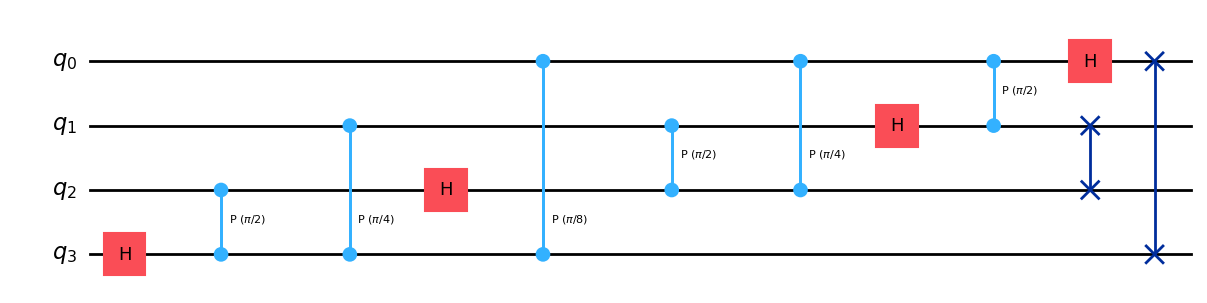

In [12]:
create_qft_circuit(4).draw(output='mpl')

In [13]:
# qc_draw, _, _, _ = create_shors_circuit(15)
# qc_draw.draw(output='mpl', fold=-1)

  N=35, a=34, t=12 counting qubits, m=6 target qubits, total=18
Target: 5, control: 4, k: 2, angle: 1.5707963267948966
Target: 5, control: 3, k: 3, angle: 0.7853981633974483
Target: 5, control: 2, k: 4, angle: 0.39269908169872414
Target: 5, control: 1, k: 5, angle: 0.19634954084936207
Target: 5, control: 0, k: 6, angle: 0.09817477042468103
Target: 4, control: 3, k: 2, angle: 1.5707963267948966
Target: 4, control: 2, k: 3, angle: 0.7853981633974483
Target: 4, control: 1, k: 4, angle: 0.39269908169872414
Target: 4, control: 0, k: 5, angle: 0.19634954084936207
Target: 3, control: 2, k: 2, angle: 1.5707963267948966
Target: 3, control: 1, k: 3, angle: 0.7853981633974483
Target: 3, control: 0, k: 4, angle: 0.39269908169872414
Target: 2, control: 1, k: 2, angle: 1.5707963267948966
Target: 2, control: 0, k: 3, angle: 0.7853981633974483
Target: 1, control: 0, k: 2, angle: 1.5707963267948966

  Drawing 6-qubit QFT circuit…


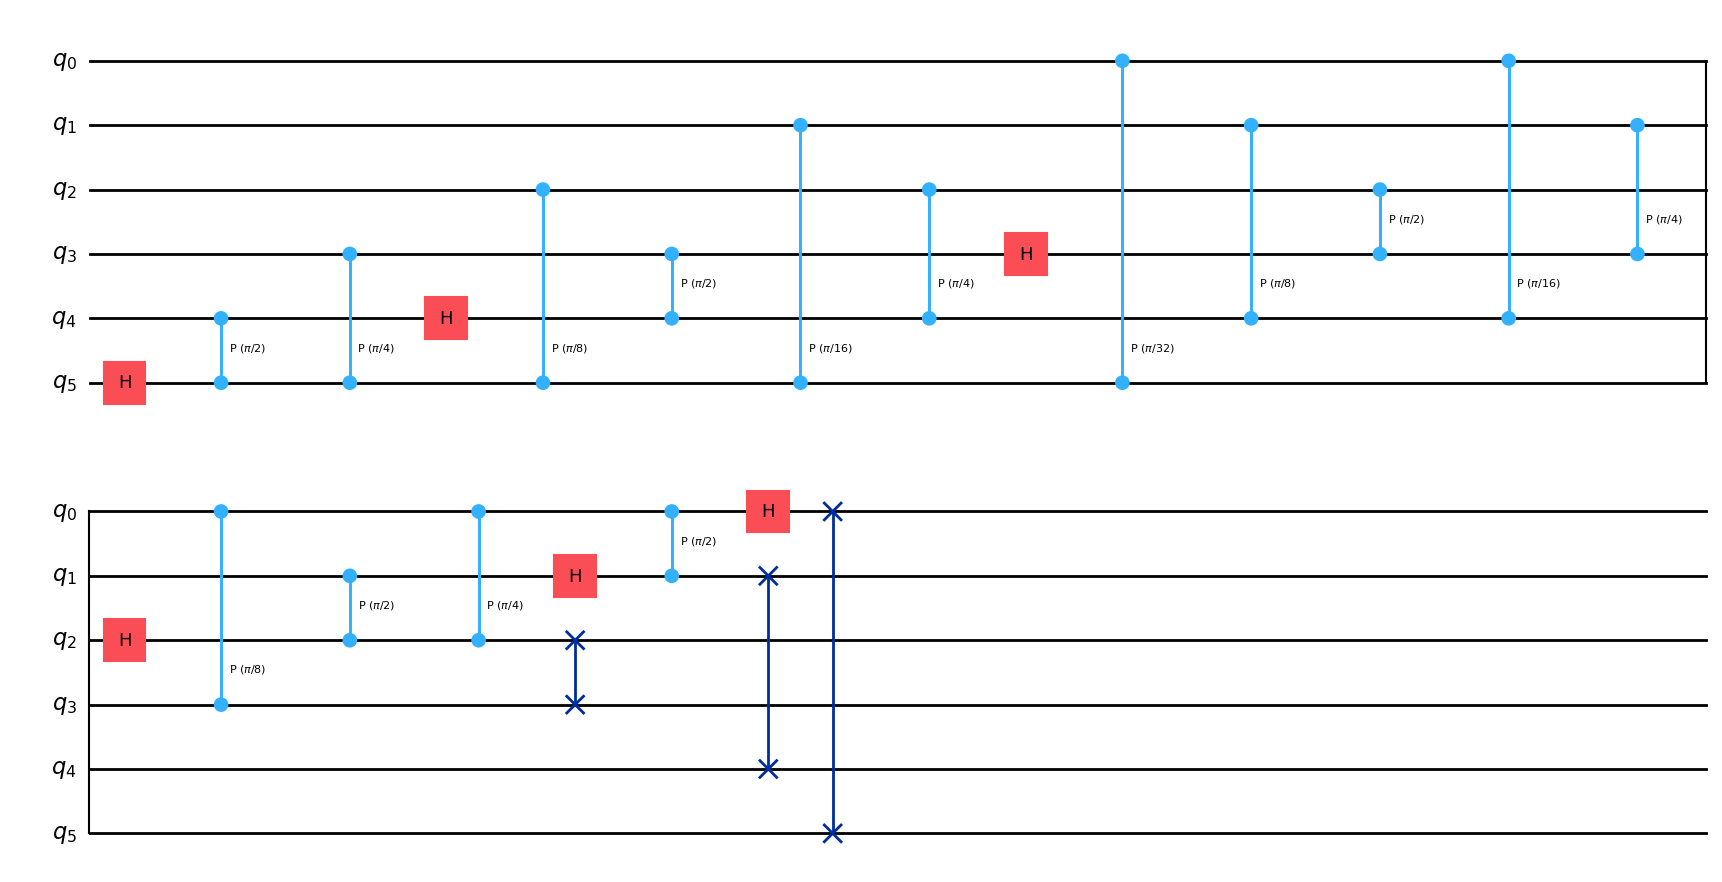

In [14]:
N_demo = 35

qc, t, m, a = create_shors_circuit(N_demo)
t_demo, m_demo, a_demo = compute_shor_params(N_demo)
qft_circuit  = create_qft_circuit(m_demo)
print(f"\n  Drawing {m_demo}-qubit QFT circuit…")
qft_circuit.draw(output='mpl')



  N=35, a=3, t=12 counting qubits, m=6 target qubits, total=18
  Drawing Shor's circuit for N=35…


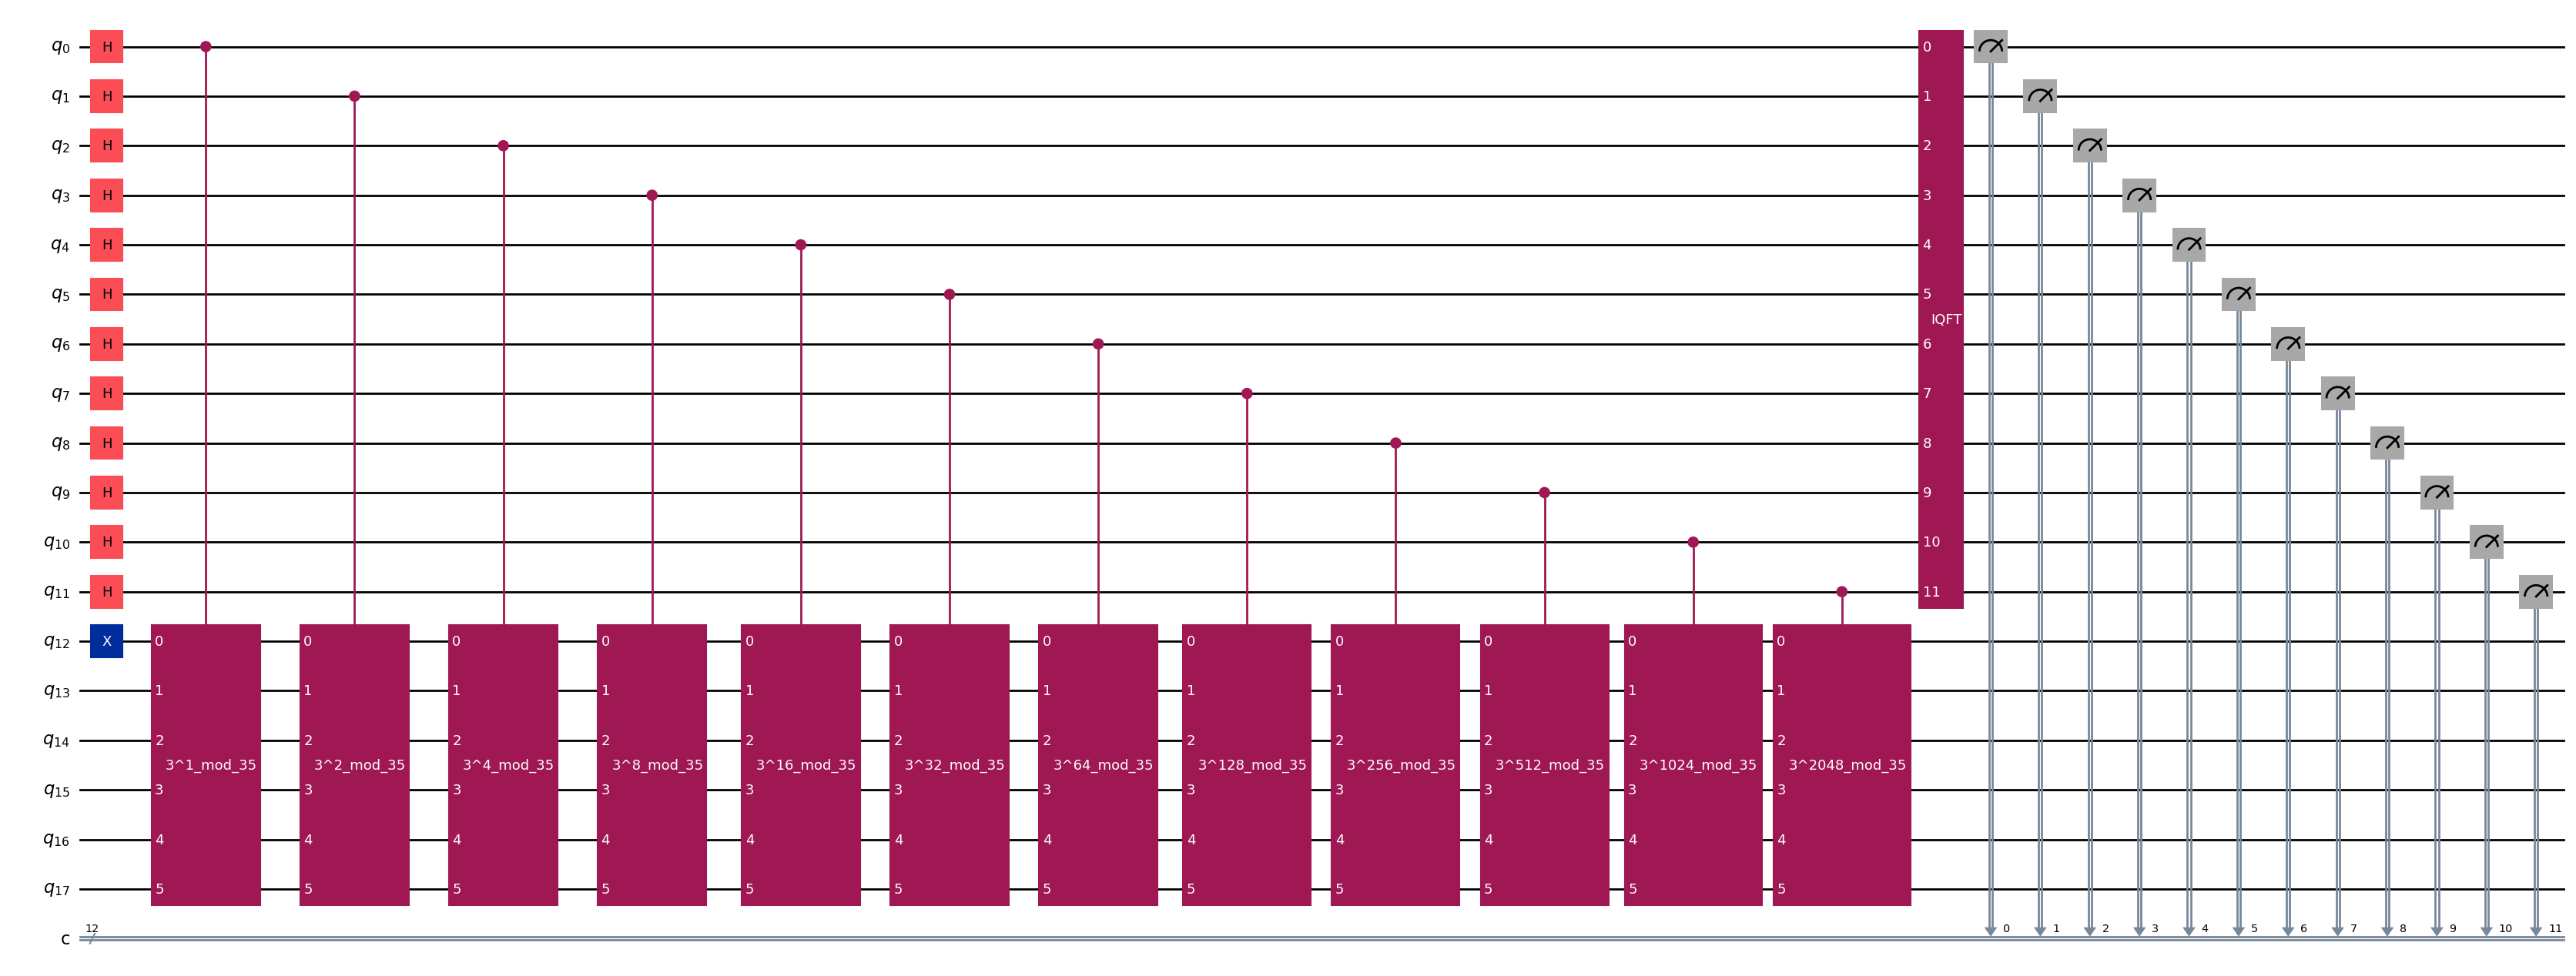

In [15]:
qc_demo, t_demo, m_demo, a_demo = create_shors_circuit(N_demo)
print(f"  Drawing Shor's circuit for N={N_demo}…")
qc_demo.draw(output='mpl', fold=-1)
